# Frontiers & Connections

## Where does machine learning + computational imaging lead?

---

*Notebook 4 of 4 — 10-minute wrap-up*

You started today by fitting a polynomial with gradient descent. You ended by reconstructing the black hole M87* from real interferometric data. Along the way, you built an imager from scratch in JAX, learned how neural networks work, and saw how implicit neural representations can encode images.

Now let's look at where these ideas lead — and how they connect to whatever you'll be working on this summer.

---

## 1. Dynamic Imaging — From Snapshots to Movies

Everything we reconstructed today was a **static image** — a single, time-averaged snapshot of M87*.

But black holes aren't static.

The accretion disk around a supermassive black hole is a violent, turbulent environment. Plasma orbits, heats, cools, and gets swallowed — all on timescales of **minutes to hours**. The image we reconstructed is a blur of all that activity, averaged over an entire night of observation.

**Dynamic imaging** asks: can we reconstruct not just an image, but a *video* from interferometric data?

This is a much harder inverse problem. Each frame of the movie has fewer data points constraining it, so the reconstruction is more underdetermined. You need stronger priors and smarter representations.

One approach — [**kine**](https://github.com/aefezeta/kine) — uses exactly the tools you learned today:

- **JAX** for automatic differentiation
- **Neural fields** (the same implicit neural representation from Notebook 3!)
- But now with a **time dimension**:

$$I(x, y, t) = \text{NN}(x, y, t;\, \theta)$$

Instead of training a network to map $(x, y) \to \text{brightness}$, you train it to map $(x, y, t) \to \text{brightness}$. The network learns a continuous representation of how the image evolves in time. Gradient descent optimizes $\theta$ to fit the interferometric data at each moment.

This is an active area of research — and now you understand the foundations it's built on.

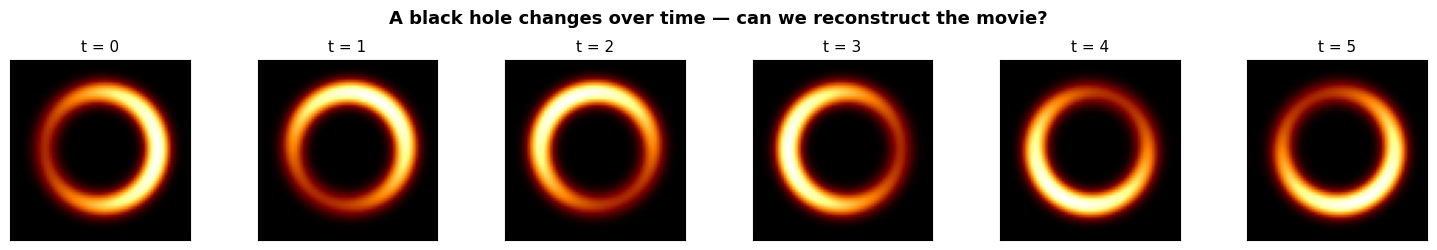

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

N = 64
y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
r = np.sqrt(x**2 + y**2).astype(float)
theta = np.arctan2(y, x)

fig, axes = plt.subplots(1, 6, figsize=(15, 2.5))
for i, t in enumerate(np.linspace(0, 2*np.pi, 6, endpoint=False)):
    # Ring with rotating bright spot
    ring = np.exp(-((r - 20)**2) / (2 * 3.0**2))
    brightness = 1.0 + 0.5 * np.cos(theta - t)
    frame = ring * brightness
    frame = frame / frame.max()
    axes[i].imshow(frame, cmap='afmhot', origin='lower')
    axes[i].set_title(f't = {i}', fontsize=11)
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.suptitle('A black hole changes over time — can we reconstruct the movie?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The bright spot orbits the ring — just like hot plasma orbiting a real black hole. Recovering this time evolution from sparse, noisy interferometric measurements is the challenge of dynamic imaging.

---

## 2. The ML Landscape — What You Learned in Context

Today we covered the foundational recipe of machine learning. Here's how it connects to the broader landscape:

| What we learned today | What it enables |
|---|---|
| Loss functions + gradient descent | The foundation of **ALL** modern ML |
| Automatic differentiation (JAX) | Training neural networks with millions of parameters |
| Neural networks | Image recognition, language models, AlphaFold |
| Inverse problems + regularization | Medical imaging (MRI, CT), seismology, microscopy |
| Implicit neural representations | 3D scene reconstruction (NeRF), video compression |

The gradient descent + neural network recipe you learned today is the **same recipe** behind ChatGPT, AlphaFold, DALL-E, and self-driving cars. The scale is different — billions of parameters instead of thousands, trained on warehouses of GPUs instead of your laptop — but the core idea is identical:

> Define a model. Define a loss. Compute gradients. Update parameters. Repeat.

---

## 3. Connections to Your Summer Research

Whatever area of astrophysics you're working in this summer, today's tools are directly relevant:

| Your research area | Connection to today's lecture |
|---|---|
| **Gravitational waves** | Matched filtering = forward model + optimization. Bayesian parameter estimation uses the same likelihood framework. |
| **CMB analysis** | Map-making from time-ordered data is an inverse problem. Power spectrum estimation uses similar techniques. |
| **Exoplanet transits** | Light curve fitting = forward model + gradient descent. Transit detection uses ML classifiers. |
| **N-body simulations** | JAX enables differentiable simulations — optimize initial conditions to match observations. |
| **Galaxy surveys** | Image deconvolution, PSF modeling, photometric redshifts — all ML applications. |
| **Stellar astrophysics** | Spectral fitting, asteroseismology — forward models + optimization. |
| **ANY data analysis** | `jax.grad` gives you free, exact gradients for any differentiable model you can write in Python. |

The common thread: if you have a **model** that predicts data and a **measurement** of real data, you can use gradient descent to find the model parameters that best explain what you observe. That's the entire game.

---

## 4. Resources & Next Steps

### Learn More

- **JAX**: [jax.readthedocs.io](https://jax.readthedocs.io) — official documentation and tutorials
- **eht-imaging**: [github.com/achael/eht-imaging](https://github.com/achael/eht-imaging) — the library we used today
- **kine**: [github.com/aefezeta/kine](https://github.com/aefezeta/kine) — dynamic imaging with neural fields
- **3Blue1Brown Neural Networks**: [youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi](https://youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) — beautiful visual explanations
- **Andrew Ng's ML Course**: [coursera.org/learn/machine-learning](https://coursera.org/learn/machine-learning) — comprehensive introduction

### Key Papers

- Event Horizon Telescope Collaboration, *"First M87 Event Horizon Telescope Results. IV. Imaging the Central Supermassive Black Hole"* (2019)
- Chael et al., *"Interferometric Imaging Directly with Closure Phases and Closure Amplitudes"* (2018) — the theory behind ehtim
- Mildenhall et al., *"NeRF: Representing Scenes as Neural Radiance Fields"* (2020) — implicit neural representations

---

### The Recipe You Learned Today

$$\boxed{\text{Model} + \text{Loss Function} + \texttt{jax.grad} + \text{Gradient Descent} = \text{Machine Learning}}$$

You started with fitting a polynomial. You ended with reconstructing a black hole. **The recipe never changed.**

---